# Superconductor Critical Temperature Prediction

This notebook builds a machine learning pipeline to predict the critical
temperature $T_c$ of superconductors from elemental features. It then applies
the trained model to a proposed A15-structured vanadium phase and investigates
how elemental substitution affects the model prediction.

**Dataset:** Hamidieh (2018), UCI Machine Learning Repository (ID 464).  
21,263 superconductors, 81 elemental features, target variable $T_c$ in Kelvin.

**Stack:** Python · pandas · scikit-learn · SQLite · matplotlib


## 1. Imports

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

## 2. Data Loading

Fetch the dataset from UCI and load into an in-memory SQLite database.
This keeps the notebook fully reproducible without any local data files.


In [20]:
# Fetch dataset from UCI repository
superconductivty_data = fetch_ucirepo(id=464)

X = superconductivty_data.data.features
y = superconductivty_data.data.targets

# Combine into one DataFrame
df = pd.concat([X, y], axis=1)

# Load into SQLite (in-memory)
conn = sqlite3.connect(":memory:")
df.to_sql("superconductors", conn, index=False, if_exists="replace")

print(f"Dataset shape: {df.shape}")
print(f"First 5 columns: {list(df.columns[:5])}")
print(f"Target column: critical_temp")

Dataset shape: (21263, 82)
First 5 columns: ['number_of_elements', 'mean_atomic_mass', 'wtd_mean_atomic_mass', 'gmean_atomic_mass', 'wtd_gmean_atomic_mass']
Target column: critical_temp


## 3. SQL Exploration

Query the database to understand the $T_c$ distribution before modeling.
The 77 K threshold is physically significant: it is the boiling point of
liquid nitrogen. Superconductors above 77 K are called high-temperature
superconductors and are far more practical for real-world applications.


In [21]:
# Summary statistics
summary = pd.read_sql("""
    SELECT
        COUNT(*)                    AS total_samples,
        ROUND(AVG(critical_temp), 2) AS mean_tc,
        ROUND(MIN(critical_temp), 2) AS min_tc,
        ROUND(MAX(critical_temp), 2) AS max_tc
    FROM superconductors
""", conn)

print(summary.to_string(index=False))

 total_samples  mean_tc  min_tc  max_tc
         21263    34.42     0.0   185.0


In [22]:
# Distribution by Tc range
distribution = pd.read_sql("""
    SELECT
        CASE
            WHEN critical_temp < 10            THEN 'Below 10 K'
            WHEN critical_temp BETWEEN 10 AND 40  THEN '10 to 40 K'
            WHEN critical_temp BETWEEN 40 AND 77  THEN '40 to 77 K'
            ELSE 'Above 77 K'
        END   AS tc_range,
        COUNT(*) AS count
    FROM superconductors
    GROUP BY tc_range
    ORDER BY MIN(critical_temp)
""", conn)

print(distribution.to_string(index=False))

  tc_range  count
Below 10 K   7729
10 to 40 K   6419
40 to 77 K   3220
Above 77 K   3895


**Observations**

- Mean $T_c$ is 34.42 K, well below 77 K. Most of the dataset is conventional superconductors.
- The 3,895 samples above 77 K are likely cuprates.
- Minimum $T_c$ is ~0.0002 K, not exactly zero. No cleaning required.


## 4. Data Preparation

In [23]:
# No unphysical zero entries found — data is clean as-is
X_clean = df.drop(columns=["critical_temp"])
y_clean = df["critical_temp"]

# 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Test samples:     {len(X_test)}")

Training samples: 17010
Test samples:     4253


## 5. Modeling

Three regression models are trained and compared.

- **Linear Regression** — baseline
- **Random Forest** — ensemble of decision trees, handles nonlinearity
- **Gradient Boosting** — sequential ensemble, often strong on tabular data

Evaluation metrics: RMSE (in Kelvin, same units as $T_c$) and $R^2$.


In [24]:
models = {
    "Linear Regression":  LinearRegression(),
    "Random Forest":      RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting":  GradientBoostingRegressor(n_estimators=100, random_state=42),
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
    r2     = r2_score(y_test, y_pred)
    results[name] = {"RMSE": round(rmse, 3), "R2": round(r2, 3), "predictions": y_pred}
    print(f"{name:<25}  RMSE = {rmse:.3f} K   R² = {r2:.3f}")

Linear Regression          RMSE = 17.378 K   R² = 0.738
Random Forest              RMSE = 9.031 K   R² = 0.929
Gradient Boosting          RMSE = 12.335 K   R² = 0.868


## 6. Results

Predicted vs actual $T_c$ for each model. A perfect model falls on the diagonal.


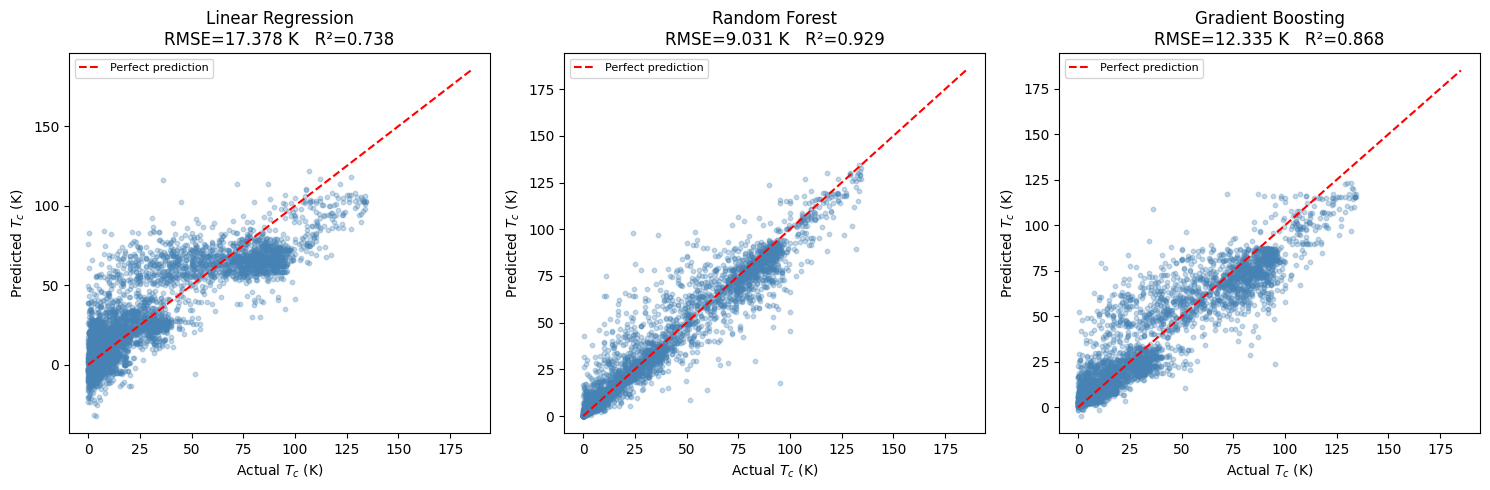

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, result) in zip(axes, results.items()):
    ax.scatter(y_test, result["predictions"], alpha=0.3, s=10, color="steelblue")
    ax.plot([0, 185], [0, 185], "r--", linewidth=1.5, label="Perfect prediction")
    ax.set_xlabel("Actual $T_c$ (K)")
    ax.set_ylabel("Predicted $T_c$ (K)")
    ax.set_title(f"{name}\nRMSE={result['RMSE']} K   R²={result['R2']}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("tc_prediction_results.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation**

- **Linear Regression** (RMSE = 17.4 K, $R^2$ = 0.74): a 17 K average error spans
  entire material families. The model predicts negative $T_c$ for low-temperature
  materials, which is physically impossible. Linear models cannot capture the
  nonlinear relationship between elemental features and $T_c$.

- **Random Forest** (RMSE = 9.0 K, $R^2$ = 0.93): best performer. Predictions
  cluster tightly along the diagonal across most of the range.

- **Gradient Boosting** (RMSE = 12.3 K, $R^2$ = 0.87): intermediate performance.

All three models struggle above 125 K. This is the cuprate region, where
high-temperature superconductivity is driven by mechanisms not captured by
BCS-derived elemental features. The dataset contains relatively few cuprate
samples, which further limits the model in that regime.


## 7. Feature Importance

Which elemental properties drive $T_c$ predictions in the Random Forest model?


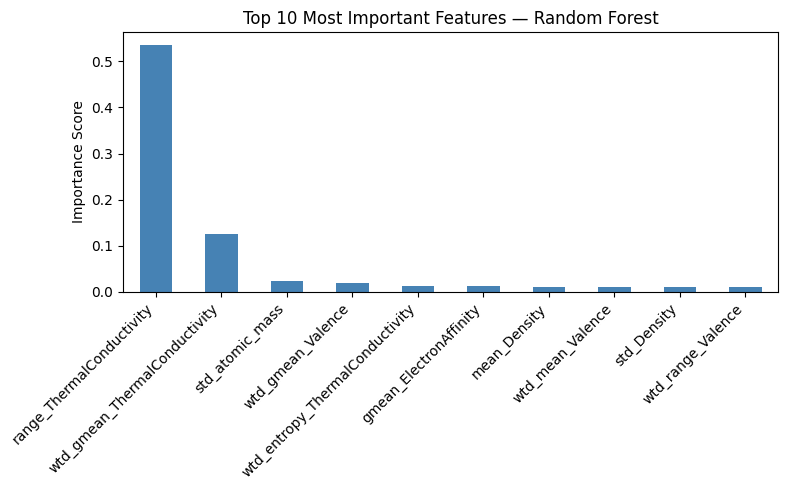

range_ThermalConductivity          0.536376
wtd_gmean_ThermalConductivity      0.126124
std_atomic_mass                    0.023099
wtd_gmean_Valence                  0.019122
wtd_entropy_ThermalConductivity    0.012260
gmean_ElectronAffinity             0.011389
mean_Density                       0.011309
wtd_mean_Valence                   0.010817
std_Density                        0.010279
wtd_range_Valence                  0.010100
dtype: float64


In [26]:
importances = pd.Series(
    models["Random Forest"].feature_importances_,
    index=X_clean.columns
).sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
importances.plot(kind="bar", color="steelblue")
plt.title("Top 10 Most Important Features — Random Forest")
plt.ylabel("Importance Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print(importances)

**Interpretation**

Thermal conductivity features account for over 66% of predictive power.
This is physically meaningful. In BCS theory, superconductivity arises from
electron-phonon coupling. Thermal conductivity reflects how phonons propagate
through the lattice. Materials with large variation in elemental thermal
conductivity across their constituent atoms tend to have stronger
electron-phonon interactions and higher $T_c$.

Valence-related features appear four times in the top ten. This is expected:
valence electrons are the ones that form Cooper pairs, the fundamental
mechanism of conventional superconductivity.


## 8. Real-World Application

The trained model is applied to a proposed A15-structured vanadium phase
characterized experimentally. The goal is to check whether the model
prediction is consistent with the observed $T_c$.

**Structure:** Cubic A15 (space group $Pm\bar{3}n$, #223), $a = 4.7336$ Å,
pure vanadium composition.  
**Experimental observation:** $T_c \approx 15$ K  
**Known BCC V reference:** $T_c \approx 5.4$ K

### 8.1 Pure A15 V prediction


In [27]:
# Elemental properties of vanadium
# Source: WebElements / CRC Handbook
# For a single-element compound, all range/std/entropy features collapse to zero.
# Mean and weighted-mean features equal the elemental value of V.

v_properties = {
    "number_of_elements":           1,
    "mean_atomic_mass":             50.9415,
    "wtd_mean_atomic_mass":         50.9415,
    "gmean_atomic_mass":            50.9415,
    "wtd_gmean_atomic_mass":        50.9415,
    "entropy_atomic_mass":          0.0,
    "wtd_entropy_atomic_mass":      0.0,
    "range_atomic_mass":            0.0,
    "wtd_range_atomic_mass":        0.0,
    "std_atomic_mass":              0.0,
    "wtd_std_atomic_mass":          0.0,
    "mean_fie":                     650.9,
    "wtd_mean_fie":                 650.9,
    "gmean_fie":                    650.9,
    "wtd_gmean_fie":                650.9,
    "entropy_fie":                  0.0,
    "wtd_entropy_fie":              0.0,
    "range_fie":                    0.0,
    "wtd_range_fie":                0.0,
    "std_fie":                      0.0,
    "wtd_std_fie":                  0.0,
    "mean_atomic_radius":           134.0,
    "wtd_mean_atomic_radius":       134.0,
    "gmean_atomic_radius":          134.0,
    "wtd_gmean_atomic_radius":      134.0,
    "entropy_atomic_radius":        0.0,
    "wtd_entropy_atomic_radius":    0.0,
    "range_atomic_radius":          0.0,
    "wtd_range_atomic_radius":      0.0,
    "std_atomic_radius":            0.0,
    "wtd_std_atomic_radius":        0.0,
    "mean_Density":                 6110.0,
    "wtd_mean_Density":             6110.0,
    "gmean_Density":                6110.0,
    "wtd_gmean_Density":            6110.0,
    "entropy_Density":              0.0,
    "wtd_entropy_Density":          0.0,
    "range_Density":                0.0,
    "wtd_range_Density":            0.0,
    "std_Density":                  0.0,
    "wtd_std_Density":              0.0,
    "mean_ElectronAffinity":        50.6,
    "wtd_mean_ElectronAffinity":    50.6,
    "gmean_ElectronAffinity":       50.6,
    "wtd_gmean_ElectronAffinity":   50.6,
    "entropy_ElectronAffinity":     0.0,
    "wtd_entropy_ElectronAffinity": 0.0,
    "range_ElectronAffinity":       0.0,
    "wtd_range_ElectronAffinity":   0.0,
    "std_ElectronAffinity":         0.0,
    "wtd_std_ElectronAffinity":     0.0,
    "mean_FusionHeat":              21.5,
    "wtd_mean_FusionHeat":          21.5,
    "gmean_FusionHeat":             21.5,
    "wtd_gmean_FusionHeat":         21.5,
    "entropy_FusionHeat":           0.0,
    "wtd_entropy_FusionHeat":       0.0,
    "range_FusionHeat":             0.0,
    "wtd_range_FusionHeat":         0.0,
    "std_FusionHeat":               0.0,
    "wtd_std_FusionHeat":           0.0,
    "mean_ThermalConductivity":     30.7,
    "wtd_mean_ThermalConductivity": 30.7,
    "gmean_ThermalConductivity":    30.7,
    "wtd_gmean_ThermalConductivity":30.7,
    "entropy_ThermalConductivity":  0.0,
    "wtd_entropy_ThermalConductivity": 0.0,
    "range_ThermalConductivity":    0.0,
    "wtd_range_ThermalConductivity":0.0,
    "std_ThermalConductivity":      0.0,
    "wtd_std_ThermalConductivity":  0.0,
    "mean_Valence":                 5.0,
    "wtd_mean_Valence":             5.0,
    "gmean_Valence":                5.0,
    "wtd_gmean_Valence":            5.0,
    "entropy_Valence":              0.0,
    "wtd_entropy_Valence":          0.0,
    "range_Valence":                0.0,
    "wtd_range_Valence":            0.0,
    "std_Valence":                  0.0,
    "wtd_std_Valence":              0.0,
}

new_material = pd.DataFrame([v_properties])[X_clean.columns]
predicted_tc = models["Random Forest"].predict(new_material)[0]

print(f"Predicted Tc — pure A15 V:      {predicted_tc:.2f} K")
print(f"Known BCC V Tc:                  5.4  K")
print(f"Experimentally observed Tc:     ~15   K")

Predicted Tc — pure A15 V:      4.36 K
Known BCC V Tc:                  5.4  K
Experimentally observed Tc:     ~15   K


**Result:** The model predicts 4.36 K, close to the known BCC V value of 5.4 K.

This is expected, not a failure. The model was trained on elemental features only.
Both BCC V and A15 V are pure vanadium: every range, standard deviation, and entropy
feature is zero. The feature vector is identical for both polymorphs.

The $T_c$ enhancement from 5.4 K to ~15 K in the A15 structure arises from
structural effects:

- The chain-like V-V arrangement along the cube faces in the A15 framework
- Enhanced electron density of states at the Fermi level $N(E_F)$
- Stronger electron-phonon coupling $\lambda$ due to reduced V-V bond distances

None of these are accessible from elemental property averages. This is a
fundamental limitation of composition-only models for polymorph-driven
superconductivity.


### 8.2 Mixed composition: V $_{1-x}$ Zr $_x$

EDX characterization indicates ~3 wt% Zr content after annealing.
Converting to atomic fraction:


In [28]:
mass_V  = 50.9415
mass_Zr = 91.224

wt_Zr = 0.03
wt_V  = 0.97

x_Zr = (wt_Zr / mass_Zr) / ((wt_Zr / mass_Zr) + (wt_V / mass_V))
x_V  = 1 - x_Zr

print(f"Atomic fraction V:  {x_V:.4f}")
print(f"Atomic fraction Zr: {x_Zr:.4f}")
print(f"Approximate formula: V{x_V:.2f}Zr{x_Zr:.2f}")

Atomic fraction V:  0.9830
Atomic fraction Zr: 0.0170
Approximate formula: V0.98Zr0.02


In [29]:
# Elemental property table — flat per-element structure
element_props = {
    "V": {
        "atomic_mass": 50.9415, "fie": 650.9,  "atomic_radius": 134.0,
        "Density": 6110.0,      "ElectronAffinity": 50.6,
        "FusionHeat": 21.5,     "ThermalConductivity": 30.7, "Valence": 5.0,
    },
    "Zr": {
        "atomic_mass": 91.224,  "fie": 640.1,  "atomic_radius": 160.0,
        "Density": 6520.0,      "ElectronAffinity": 41.1,
        "FusionHeat": 21.0,     "ThermalConductivity": 22.6, "Valence": 4.0,
    },
    "O": {
        # Oxide-relevant values assuming O2- substitution on the metal site.
        # Gas-phase O properties are not used — they are not physically
        # meaningful in a metallic lattice. Density approximated from V2O5.
        # Thermal conductivity taken as representative of transition-metal oxides.
        "atomic_mass": 15.999,  "fie": 1313.9, "atomic_radius": 66.0,
        "Density": 4230.0,      "ElectronAffinity": 141.0,
        "FusionHeat": 0.222,    "ThermalConductivity": 18.0, "Valence": 2.0,
    },
}

property_names = list(element_props["V"].keys())

def build_features(el2, x2):
    """Build the 81-feature vector for V(1-x)El2(x) at composition x2."""
    x1 = 1 - x2
    features = {"number_of_elements": 2}
    for p in property_names:
        v1, v2 = element_props["V"][p], element_props[el2][p]
        wm = x1 * v1 + x2 * v2
        wg = (v1 ** x1) * (v2 ** x2)
        we = -(x1 * np.log(x1 + 1e-10) * v1 + x2 * np.log(x2 + 1e-10) * v2)
        wr = abs(v1 - v2)
        ws = np.sqrt(x1 * (v1 - wm)**2 + x2 * (v2 - wm)**2)
        for prefix, val in [("mean", wm), ("wtd_mean", wm), ("gmean", wg),
                             ("wtd_gmean", wg), ("entropy", we),
                             ("wtd_entropy", we), ("range", wr),
                             ("wtd_range", wr), ("std", ws), ("wtd_std", ws)]:
            features[f"{prefix}_{p}"] = val
    return features

# Predict at EDX composition
vzr_features    = build_features("Zr", x_Zr)
new_material_vzr = pd.DataFrame([vzr_features])[X_clean.columns]
predicted_tc_vzr = models["Random Forest"].predict(new_material_vzr)[0]

print(f"Predicted Tc — pure A15 V:           4.36 K")
print(f"Predicted Tc — V{x_V:.2f}Zr{x_Zr:.2f} A15:  {predicted_tc_vzr:.2f} K")
print(f"Experimentally observed Tc:          ~15   K")

Predicted Tc — pure A15 V:           4.36 K
Predicted Tc — V0.98Zr0.02 A15:  8.19 K
Experimentally observed Tc:          ~15   K


**Result:** Introducing 2 at% Zr raises the prediction from 4.36 K to 8.19 K,
nearly double the pure V prediction.

This occurs because a second element activates the variance features that were
zero for pure V. In particular, `range_ThermalConductivity` (V: 30.7 W/m·K,
Zr: 22.6 W/m·K) and `range_Valence` (V: 5, Zr: 4) become nonzero. These are
among the highest-importance features in the model.

The remaining gap between 8.19 K and 15 K is the structural $T_c$ enhancement
from the A15 geometry, which no elemental model can recover.


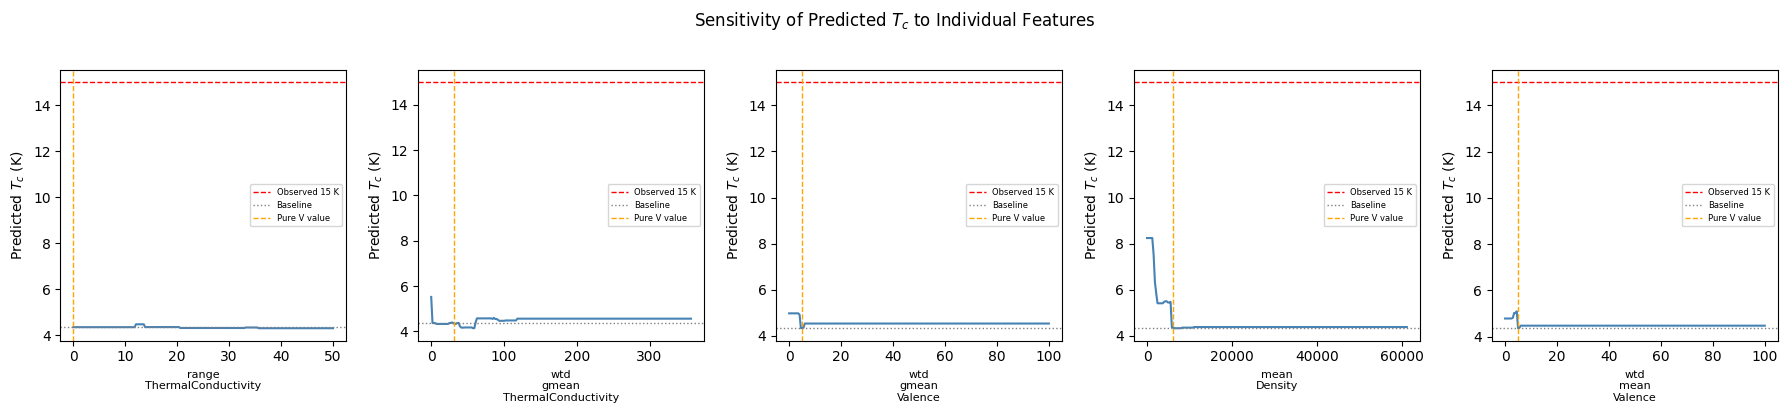

In [30]:
features_to_probe = [
    "range_ThermalConductivity",
    "wtd_gmean_ThermalConductivity",
    "wtd_gmean_Valence",
    "mean_Density",
    "wtd_mean_Valence",
]

fig, axes = plt.subplots(1, len(features_to_probe), figsize=(18, 4))

for ax, feature in zip(axes, features_to_probe):
    baseline    = new_material[feature].values[0]
    test_values = np.linspace(0, baseline * 10 + 50, 200)

    predictions = []
    for val in test_values:
        modified          = new_material.copy()
        modified[feature] = val
        predictions.append(models["Random Forest"].predict(modified)[0])

    ax.plot(test_values, predictions, color="steelblue", linewidth=1.5)
    ax.axhline(y=15,   color="red",    linestyle="--", linewidth=1, label="Observed 15 K")
    ax.axhline(y=4.36, color="gray",   linestyle=":",  linewidth=1, label="Baseline")
    ax.axvline(x=baseline, color="orange", linestyle="--", linewidth=1, label="Pure V value")
    ax.set_xlabel(feature.replace("_", "\n"), fontsize=8)
    ax.set_ylabel("Predicted $T_c$ (K)")
    ax.legend(fontsize=6)

plt.suptitle("Sensitivity of Predicted $T_c$ to Individual Features", y=1.02)
plt.tight_layout()
plt.savefig("inverse_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

**Result:** No single feature, varied alone, can push the prediction to 15 K.
The blue line never reaches the red dashed line in any panel.

This confirms the earlier conclusion. For a single-element system, all variance
features are structurally constrained to zero. The model has essentially never
seen a single-element compound with $T_c$ above ~10 K in training. It cannot
extrapolate there from elemental means alone. The 15 K enhancement is
driven by crystal geometry, not by elemental properties.


## 10. Composition Optimization

Scan predicted $T_c$ across the full composition range for two substitution
systems: V $_{1-x}$ Zr $_x$ and V $_{1-x}$ O $_x$ (up to $x = 0.5$).

**Note on oxygen modeling:** O is treated as $O^{2-}$ substituting on the metal
site. Properties are approximated using oxide-relevant values rather than
gas-phase values, which are not physically meaningful in a metallic lattice.
Density is approximated from V $_2$ O $_5$ ; thermal conductivity is taken as
representative of transition-metal oxides. This introduces uncertainty in
absolute predictions but preserves directional trends.


In [33]:
x_vals = np.linspace(0.001, 0.50, 100)
tc_zr, tc_o = [], []

for x in x_vals:
    df_zr = pd.DataFrame([build_features("Zr", x)])[X_clean.columns]
    tc_zr.append(models["Random Forest"].predict(df_zr)[0])

    df_o = pd.DataFrame([build_features("O", x)])[X_clean.columns]
    tc_o.append(models["Random Forest"].predict(df_o)[0])

tc_zr = np.array(tc_zr)
tc_o  = np.array(tc_o)

best_x_zr,  best_tc_zr = x_vals[np.argmax(tc_zr)], tc_zr.max()
best_x_o,   best_tc_o  = x_vals[np.argmax(tc_o)],  tc_o.max()

print(f"V1-xZrx  optimal x = {best_x_zr:.3f}   predicted Tc = {best_tc_zr:.2f} K")
print(f"V1-xOx   optimal x = {best_x_o:.3f}   predicted Tc = {best_tc_o:.2f} K")

V1-xZrx  optimal x = 0.238   predicted Tc = 8.82 K
V1-xOx   optimal x = 0.314   predicted Tc = 17.99 K


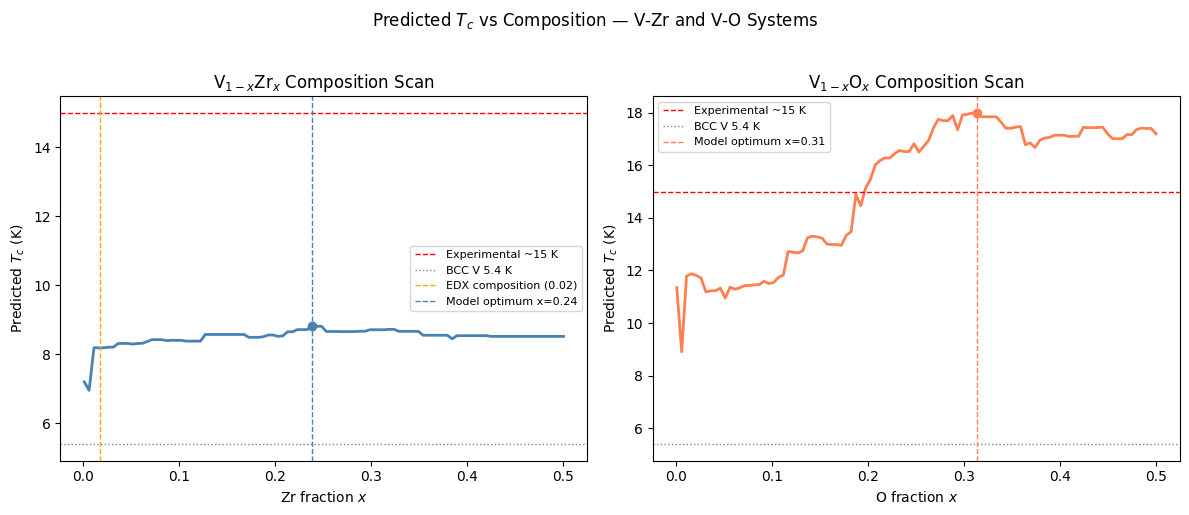

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# V1-xZrx
axes[0].plot(x_vals, tc_zr, color="steelblue", linewidth=2)
axes[0].axhline(y=15,  color="red",  linestyle="--", linewidth=1, label="Experimental ~15 K")
axes[0].axhline(y=5.4, color="gray", linestyle=":",  linewidth=1, label="BCC V 5.4 K")
axes[0].axvline(x=x_Zr,       color="orange",    linestyle="--", linewidth=1, label=f"EDX composition ({x_Zr:.2f})")
axes[0].axvline(x=best_x_zr,  color="steelblue", linestyle="--", linewidth=1, label=f"Model optimum x={best_x_zr:.2f}")
axes[0].scatter([best_x_zr], [best_tc_zr], color="steelblue", zorder=5)
axes[0].set_xlabel("Zr fraction $x$")
axes[0].set_ylabel("Predicted $T_c$ (K)")
axes[0].set_title("V$_{1-x}$Zr$_x$ Composition Scan")
axes[0].legend(fontsize=8)

# V1-xOx
axes[1].plot(x_vals, tc_o, color="coral", linewidth=2)
axes[1].axhline(y=15,  color="red",   linestyle="--", linewidth=1, label="Experimental ~15 K")
axes[1].axhline(y=5.4, color="gray",  linestyle=":",  linewidth=1, label="BCC V 5.4 K")
axes[1].axvline(x=best_x_o, color="coral", linestyle="--", linewidth=1, label=f"Model optimum x={best_x_o:.2f}")
axes[1].scatter([best_x_o], [best_tc_o], color="coral", zorder=5)
axes[1].set_xlabel("O fraction $x$")
axes[1].set_ylabel("Predicted $T_c$ (K)")
axes[1].set_title("V$_{1-x}$O$_x$ Composition Scan")
axes[1].legend(fontsize=8)

plt.suptitle("Predicted $T_c$ vs Composition — V-Zr and V-O Systems", y=1.02)
plt.tight_layout()
plt.savefig("composition_scan.png", dpi=150, bbox_inches="tight")
plt.show()

**Results**

| System | Model optimum $x$ | Peak predicted $T_c$ |
|--------|-------------------|----------------------|
| V $_{1-x}$ Zr $_x$ | 0.238 | 8.82 K |
| V $_{1-x}$ O $_x$  | 0.314 | 17.99 K |

**V-Zr:** The prediction rises sharply at low Zr content then plateaus near 8.8 K.
The EDX-measured 2 at% Zr already captures most of the achievable $T_c$ enhancement
from Zr substitution. Adding more Zr past ~5% does not help. The Zr scan confirms
that elemental Zr substitution alone cannot account for the observed 15 K,
regardless of concentration.

**V-O:** The model predicts $T_c$ crosses 15 K around $x = 0.15$ and peaks near
18 K at $x = 0.31$. This must be interpreted carefully. At 15-31 at% oxygen
the A15 phase would not be stable: vanadium oxides in that composition range
are not superconductors, and the model has no knowledge of phase stability.

However, the directional result is physically interesting. Even small oxygen
content at levels where the A15 phase remains stable could contribute to the
observed 15 K if oxygen is substituting into the structure rather than forming
a separate oxide phase. The jagged shape of the V-O curve reflects Random Forest
interpolation in a sparse region of training data.

This raises a testable experimental question: could trace oxygen substitution
below 5 at% be contributing to the elevated $T_c$? This warrants
oxygen-sensitive characterization such as EELS or more precise EDX calibration.


## 11. Summary

### Model performance

The Random Forest model achieves $R^2 = 0.929$ and RMSE = 9.03 K on the
UCI superconductor dataset, outperforming both Linear Regression and
Gradient Boosting. Thermal conductivity features dominate predictions,
consistent with the central role of electron-phonon coupling in BCS theory.

### Application to proposed A15 V phase

| System | Predicted $T_c$ | Source |
|--------|----------------|--------|
| BCC V (reference) | 5.4 K | Experimental literature |
| Pure A15 V | 4.36 K | This model |
| V $_{0.98}$ Zr $_{0.02}$ A15 | 8.19 K | This model |
| Experimental observation | ~15 K | Magnetization measurement |

The model captures the direction of the $T_c$ trend correctly. Zr substitution
raises the prediction by activating variance features that are zero for pure V.
The remaining gap between 8.19 K and 15 K is the structural $T_c$ enhancement
from the A15 crystal geometry.

### Key conclusion

The observed $T_c \approx 15$ K cannot be explained by elemental composition
alone. The dominant contribution is structural: the A15 framework enhances
$N(E_F)$ and electron-phonon coupling beyond what any elemental model can
predict. This is consistent with the known behavior of A15 superconductors
such as Nb $_3$ Sn and V $_3$ Si.

### Limitations and future directions

- Structural descriptors (lattice parameters, space group encoding, bond lengths)
  are required to distinguish polymorphs of the same element.
- DFT-derived quantities such as $N(E_F)$ and $\lambda$ would substantially
  improve predictions in the single-element and low-substitution regime.
- Phase stability constraints are absent from the current model. Predictions
  at high substitution fractions should be treated as extrapolations.
- SHAP-based inverse analysis would provide a more rigorous decomposition
  of which feature changes most efficiently close the gap to 15 K.
